In [35]:
import pandas as pd
import numpy as np
from scipy.stats import zscore, linregress
import matplotlib.pyplot as plt
import sys
import geopandas as gpd
import statsmodels.formula.api as smf
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import cross_val_score, KFold, cross_val_predict
from sklearn.linear_model import LinearRegression
import shap
import seaborn as sns

def grouped_permutation_importance(model, X, y, groups, n_repeats=10, random_state=42):
    """
    groups: dict mapping group_name -> list of column names to permute together
    """
    rng = np.random.RandomState(random_state)
    baseline_score = model.score(X, y)
    results = {}
    
    for group_name, cols in groups.items():
        drop_scores = []
        for _ in range(n_repeats):
            X_permuted = X.copy()
            # Shuffle all columns in the group using the SAME row order,
            # so their joint relationship is scrambled together
            shuffled_idx = rng.permutation(len(X_permuted))
            X_permuted[cols] = X_permuted[cols].values[shuffled_idx]
            score = model.score(X_permuted, y)
            drop_scores.append(baseline_score - score)
        results[group_name] = {
            'importance_mean': np.mean(drop_scores),
            'importance_std': np.std(drop_scores)
        }
    return pd.DataFrame(results).T.sort_values('importance_mean', ascending=False)

def loco_test(X_full, y, drop_var, cv):
    X_reduced = X_full.drop(columns=[drop_var])
    rf_test = RandomForestRegressor(n_estimators=100, random_state=42)
    r2 = cross_val_score(rf_test, X_reduced, y, cv=cv, scoring='r2').mean()
    return r2

def loco_test_vars(X_full, y, drop_vars, cv):
    X_reduced = X_full.drop(columns=drop_vars)
    rf_test = RandomForestRegressor(n_estimators=100, random_state=42)
    r2 = cross_val_score(rf_test, X_reduced, y, cv=cv, scoring='r2').mean()
    return r2

def find_linear_relationship (df, variable1):
    x = df[variable1]
    y = df["10cm_area"]

    # Simple regression: flood area ~ rainfall intensity
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    r2_simple = r_value**2
    if p_value <0.005:
        p_value = '<0.05'
    else:
        p_value = round(p_value, 2)
    # print(" Simple:", f"{r2_simple:.2f}", p_value)  
    return [r2_simple, p_value]

sys.path.insert(1, '../ProcessEvents')
from config import CATCHMENT_LOOKUP_DICT, ENSEMBLE_MEMBERS, CATCHMENTS

### Get event data

In [19]:
fp = f"/scratch/hydro4/users/kv25483/FutureFlood/Data/EventDetails_v4/all_catchments.pkl"
rainfall_events_all_df = pd.read_pickle(fp)
rainfall_events_all_df = rainfall_events_all_df[rainfall_events_all_df['max_precip']<130].copy()
rainfall_events_all_df["length"] = (rainfall_events_all_df["stop_idx"] - rainfall_events_all_df["start_idx"]).astype("float32")
rainfall_events_all_df['random_variable'] = np.random.normal(size=len(rainfall_events_all_df))

In [39]:
# subset = rainfall_events_all_df[rainfall_events_all_df['catchment_num'] in ['33_b', '23', '105', '40']].copy()
subset = rainfall_events_all_df# [rainfall_events_all_df["catchment_num"].isin(['33_b', '23', '105', '40', '106', '25'])].copy()
subset = subset.sample(n=5000, random_state=42)  # adjust size to something that runs in seconds
subset.reset_index(inplace=True, drop=True)

### Create model instances (needed for testing)

In [36]:
rf = RandomForestRegressor(n_estimators=100,max_depth=None,random_state=42)
lr = LinearRegression()
cv = KFold(n_splits=5, shuffle=True, random_state=42)

### Feature selection

Remove variables which carry no meaning

Add new derived versions of variables

In [54]:
for level in ['t50', 't60', 't80']:
    subset[f'cluster_mean_intensity_{level}'] = (
        subset[f'cluster_rain_total_{level}'] / subset[f'cluster_n_cells_{level}'].replace(0, np.nan))

In [57]:
predictor_variables = [col for col in subset.columns if col not in ['10cm_area', '10cm_volume', '30cm_area', '30cm_volume']]

# Define X (predictors) and Y (response)
X = subset[predictor_variables]
y = subset['10cm_area']

### Create baseline version of model with all variables included

In [46]:
baseline_r2 = cross_val_score(rf, X, y, cv=cv, scoring='r2').mean()
print(f"Full model R²: {baseline_r2:.4f}\n")

Full model R²: 0.7999



### Test whether dropping any of the cluster rain vars decreases model performance

In [65]:
cluster_rain_vars = ['cluster_rain_total_t50', 'cluster_rain_total_t60',  'cluster_rain_total_t80', 
                      'cluster_n_cells_t50', 'cluster_n_cells_t60','cluster_n_cells_t80',
               "cluster_mean_intensity_t50","cluster_mean_intensity_t60", "cluster_mean_intensity_t80"  ]

In [70]:
r2_dropped = loco_test_vars(X, y, cluster_rain_vars, cv)
print(f"Drop cluster_rain_vars → R² = {r2_dropped:.4f}  (Δ = {baseline_r2 - r2_dropped:+.4f})")

Drop cluster_rain_vars → R² = 0.8019  (Δ = -0.0020)


### Compare performance of each of the cluster rain variables on their own

In [66]:
rf_shallow = RandomForestRegressor(n_estimators=100, max_depth=4, min_samples_leaf=20, random_state=42)

for var in cluster_rain_vars:
    r2_solo = cross_val_score(rf_shallow, X[[var]], y, cv=cv, scoring='r2').mean()
    print(f"{var:35s} alone → R² = {r2_solo:.4f}")

cluster_rain_total_t50              alone → R² = 0.0382
cluster_rain_total_t60              alone → R² = 0.0384
cluster_rain_total_t80              alone → R² = 0.0595
cluster_n_cells_t50                 alone → R² = 0.0050
cluster_n_cells_t60                 alone → R² = 0.0045
cluster_n_cells_t80                 alone → R² = 0.0018
cluster_mean_intensity_t50          alone → R² = 0.0627
cluster_mean_intensity_t60          alone → R² = 0.0742
cluster_mean_intensity_t80          alone → R² = 0.0961


In [67]:
for var in cluster_rain_vars:
    rho = subset[var].corr(y, method='spearman')
    print(f"{var:35s} Spearman r with target = {rho:.3f}")

cluster_rain_total_t50              Spearman r with target = 0.226
cluster_rain_total_t60              Spearman r with target = 0.234
cluster_rain_total_t80              Spearman r with target = 0.277
cluster_n_cells_t50                 Spearman r with target = 0.103
cluster_n_cells_t60                 Spearman r with target = 0.095
cluster_n_cells_t80                 Spearman r with target = 0.081
cluster_mean_intensity_t50          Spearman r with target = 0.211
cluster_mean_intensity_t60          Spearman r with target = 0.249
cluster_mean_intensity_t80          Spearman r with target = 0.318


In [71]:
X[['cluster_rain_total_t50', 'cluster_rain_total_t60', 'cluster_rain_total_t80',
   'cluster_mean_intensity_t50', 'cluster_mean_intensity_t60', 'cluster_mean_intensity_t80',
   'max_precip', 'total_acc']].corr(method='spearman')

,cluster_rain_total_t50,cluster_rain_total_t60,cluster_rain_total_t80,cluster_mean_intensity_t50,cluster_mean_intensity_t60,cluster_mean_intensity_t80,max_precip,total_acc
cluster_rain_total_t50,1.000000,0.890799,0.592954,-0.274328,-0.147571,0.115456,0.225542,0.212988
cluster_rain_total_t60,0.890799,1.000000,0.687515,-0.066664,-0.124266,0.175467,0.298883,0.230607
cluster_rain_total_t80,0.592954,0.687515,1.000000,0.369550,0.389085,0.422852,0.586300,0.327722
cluster_mean_intensity_t50,-0.274328,-0.066664,0.369550,1.000000,0.885233,0.797426,0.784661,0.344633
cluster_mean_intensity_t60,-0.147571,-0.124266,0.389085,0.885233,1.000000,0.874724,0.856866,0.383711
cluster_mean_intensity_t80,0.115456,0.175467,0.422852,0.797426,0.874724,1.000000,0.974048,0.440529
max_precip,0.225542,0.298883,0.586300,0.784661,0.856866,0.974048,1.000000,0.459357
total_acc,0.212988,0.230607,0.327722,0.344633,0.383711,0.440529,0.459357,1.000000


In [72]:
# Does dropping cluster-rain vars hurt disproportionately for specific event types?
results['pred_full'] = cross_val_predict(rf, X, y, cv=cv, n_jobs=-1)
results['pred_reduced'] = cross_val_predict(rf, X.drop(columns=cluster_rain_vars), y, cv=cv, n_jobs=-1)

results['loss_from_dropping'] = (results['y_true'] - results['pred_reduced']).abs() - (results['y_true'] - results['pred_full']).abs()

# Where does dropping them hurt most?
results.sort_values('loss_from_dropping', ascending=False).head(20)[variables + ['y_true']]

NameError: name 'results' is not defined

In [64]:
# Dropping one at a time
for var in ['cluster_n_cells_t50', 'cluster_n_cells_t60', 'cluster_n_cells_t80',
            'cluster_mean_intensity_t50', 'cluster_mean_intensity_t60', 'cluster_mean_intensity_t80']:
    r2_dropped = cross_val_score(rf, X.drop(columns=[var]), y, cv=cv, scoring='r2').mean()
    print(f"Drop {var:30s} → Δ R² = {baseline_r2 - r2_dropped:+.4f}")

Drop cluster_n_cells_t50            → Δ R² = +0.0008
Drop cluster_n_cells_t60            → Δ R² = +0.0001
Drop cluster_n_cells_t80            → Δ R² = -0.0001
Drop cluster_mean_intensity_t50     → Δ R² = -0.0013
Drop cluster_mean_intensity_t60     → Δ R² = +0.0001
Drop cluster_mean_intensity_t80     → Δ R² = -0.0011


In [69]:
# from itertools import combinations

# threshold_vars = {
#     't50': ['cluster_n_cells_t50', 'cluster_mean_intensity_t50'],
#     't60': ['cluster_n_cells_t60', 'cluster_mean_intensity_t60'],
#     't80': ['cluster_n_cells_t80', 'cluster_mean_intensity_t80'],
# }

# other_vars = [v for v in variables if v not in sum(threshold_vars.values(), [])]

# # Test: all three thresholds, each pair, and each single threshold alone
# subsets_to_test = {
#     'all_three': ['t50', 't60', 't80'],
#     't50+t60':   ['t50', 't60'],
#     't50+t80':   ['t50', 't80'],
#     't60+t80':   ['t60', 't80'],
#     't50_only':  ['t50'],
#     't60_only':  ['t60'],
#     't80_only':  ['t80'],
# }

# for label, thresholds in subsets_to_test.items():
#     cols = other_vars + sum([threshold_vars[t] for t in thresholds], [])
#     r2 = cross_val_score(rf, X[cols], y, cv=cv, scoring='r2').mean()
#     print(f"{label:12s} → R² = {r2:.4f}  ({len(cols)} total predictors)")

Identify groups of variables with overlapping meaning

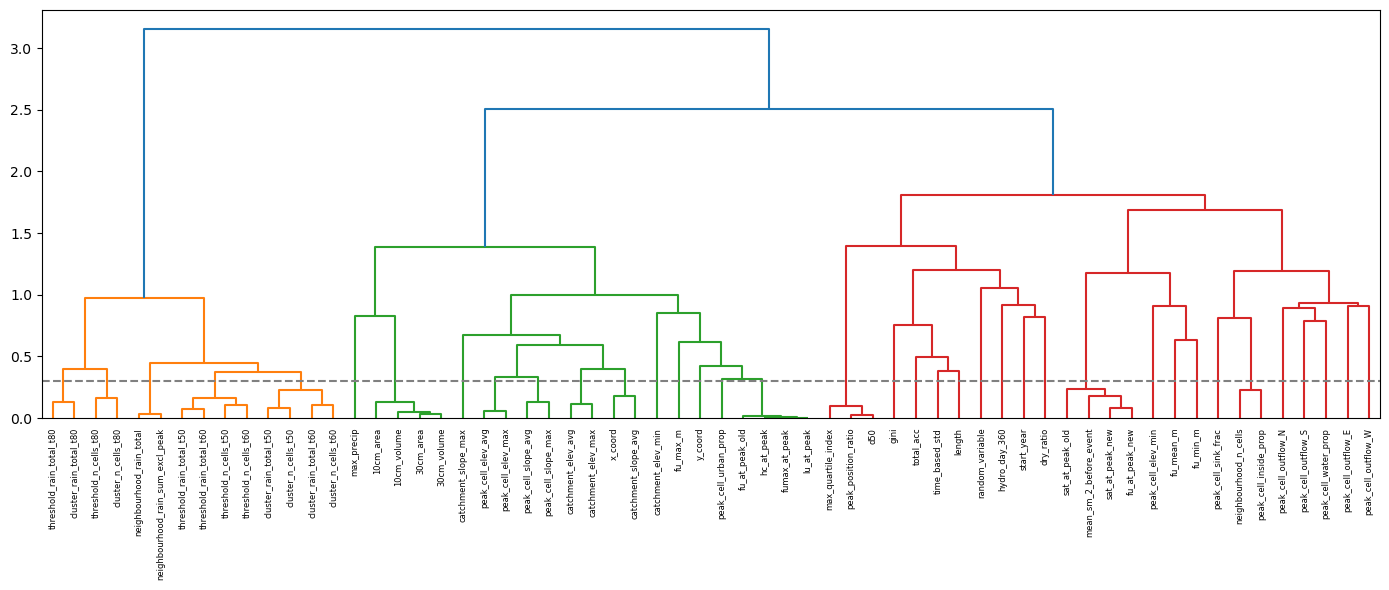

Group 1: ['threshold_rain_total_t80', 'threshold_n_cells_t80', 'cluster_rain_total_t80', 'cluster_n_cells_t80']
Group 2: ['neighbourhood_rain_total', 'neighbourhood_rain_sum_excl_peak', 'threshold_rain_total_t50', 'threshold_n_cells_t50', 'cluster_rain_total_t50', 'cluster_n_cells_t50', 'threshold_rain_total_t60', 'threshold_n_cells_t60', 'cluster_rain_total_t60', 'cluster_n_cells_t60']
Group 3: ['10cm_area', '10cm_volume', '30cm_area', '30cm_volume']
Group 5: ['peak_cell_slope_avg', 'peak_cell_slope_max', 'peak_cell_elev_avg', 'peak_cell_elev_max']
Group 6: ['x_coord', 'catchment_slope_avg', 'catchment_elev_avg', 'catchment_elev_max']
Group 8: ['y_coord', 'hc_at_peak', 'fu_at_peak_old', 'fumax_at_peak', 'lu_at_peak', 'peak_cell_urban_prop']
Group 11: ['peak_position_ratio', 'd50', 'max_quartile_index']
Group 12: ['total_acc', 'time_based_std', 'length']
Group 18: ['mean_sm_2_before_event', 'sat_at_peak_new', 'sat_at_peak_old', 'fu_at_peak_new']
Group 22: ['neighbourhood_n_cells', 'pea

In [26]:
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform

corr = subset.corr(method='spearman').abs()
dist = 1 - corr
condensed = squareform(dist, checks=False)
linkage = hierarchy.ward(condensed)

plt.figure(figsize=(14, 6))
hierarchy.dendrogram(linkage, labels=subset.columns, leaf_rotation=90)
plt.axhline(0.3, color='grey', linestyle='--')
plt.tight_layout()
plt.show()

from scipy.cluster.hierarchy import fcluster
cluster_ids = fcluster(linkage, t=0.5, criterion='distance')
for gid, members in pd.Series(cluster_ids, index=subset.columns).groupby(cluster_ids):
    if len(members) > 1:
        print(f"Group {gid}: {list(members.index)}")

### Work out which variables to include from overlapping set
    Rainfall variables:

In [70]:
# rf = RandomForestRegressor(n_estimators=100,max_depth=None,random_state=42)

# for var in ['cluster_rain_total_t50', 'cluster_n_cells_t50', 'cluster_mean_intensity_t50']:
#     r2_solo = cross_val_score(rf, X[[var]], y, cv=cv, scoring='r2').mean()
#     print(f"{var:35s} alone → R² = {r2_solo:.4f}")

### Compare performance of random forest and linear regression

In [149]:
predictor_variables = [col for col in subset.columns if col not in ['10cm_area', '10cm_volume', '30cm_area', '30cm_volume']]

# Define X (predictors) and Y (response)
X = subset[predictor_variables]
y = subset['10cm_area']

In [29]:
baseline_r2 = cross_val_score(rf, X, y, cv=cv, scoring='r2').mean()
print(f"Full model R²: {baseline_r2:.4f}\n")

for var in ['fumax_at_peak', 'fu_at_peak_old', 'lu_at_peak']:
    r2_dropped = loco_test_vars(X, y, [var, 'fumax_at_peak', "fu_at_peak_new"], cv)
    print(f"Drop {var:20s} → R² = {r2_dropped:.4f}  (Δ = {baseline_r2 - r2_dropped:+.4f})")

Full model R²: 0.7862

Drop fumax_at_peak        → R² = 0.7869  (Δ = -0.0007)
Drop fu_at_peak_old       → R² = 0.7868  (Δ = -0.0006)
Drop lu_at_peak           → R² = 0.7828  (Δ = +0.0033)


In [145]:
# del X['sat_at_peak_new']
# del X['sat_at_peak_old']
# del X['fu_at_peak_new']
# del X['fu_mean_m']

In [152]:
groups = {
    'storage_capacity': ['fumax_at_peak', 'lu_at_peak'],
    'event_length_family': ['length', 'total_acc', 'dry_ratio'],  # adjust to actual names
    'mean_sm_2_before_event': ['mean_sm_2_before_event', 'fu_at_peak_new',],  # single-variable "groups" still work fine
    'max_precip': ['max_precip'],
    'random_variable': ['random_variable'],
    # ... add remaining variables as single-item groups
}

rf.fit(X, y)
grouped_importance = grouped_permutation_importance(rf, X, y, groups)
print(grouped_importance)

                        importance_mean  importance_std
event_length_family            0.336563        0.015093
storage_capacity               0.270100        0.008741
max_precip                     0.139405        0.004860
mean_sm_2_before_event         0.004715        0.000212
random_variable                0.002756        0.000117


In [161]:
for var in ['fumax_at_peak', 'lu_at_peak', 'mean_sm_2_before_event', 'fu_at_peak_new', 'fu_at_peak_old',
           "sat_at_peak_new", "sat_at_peak_old", 'fu_mean_m', 'fu_min_m','fu_max_m',]:
    r2_solo = cross_val_score(rf, X[[var]], y, cv=cv, scoring='r2').mean()
    print(f"{var:35s} alone → R² = {r2_solo:.4f}")

fumax_at_peak                       alone → R² = 0.2469
lu_at_peak                          alone → R² = 0.2874
mean_sm_2_before_event              alone → R² = -0.4359
fu_at_peak_new                      alone → R² = -0.3261
fu_at_peak_old                      alone → R² = 0.0944
sat_at_peak_new                     alone → R² = -0.4022
sat_at_peak_old                     alone → R² = -0.4642
fu_mean_m                           alone → R² = -0.1311
fu_min_m                            alone → R² = 0.0284
fu_max_m                            alone → R² = -0.0301


In [163]:
baseline_r2 = cross_val_score(rf, X[['fumax_at_peak', 'lu_at_peak', 'mean_sm_2_before_event', 'fu_at_peak_new', 'fu_at_peak_old',
           "sat_at_peak_new", "sat_at_peak_old", 'fu_mean_m', 'fu_min_m','fu_max_m',]], y, cv=cv, scoring='r2').mean()

for var in ['fumax_at_peak', 'lu_at_peak', 'mean_sm_2_before_event', 'fu_at_peak_new', 'fu_at_peak_old',
           "sat_at_peak_new", "sat_at_peak_old", 'fu_mean_m', 'fu_min_m','fu_max_m',]:
    r2_dropped = cross_val_score(rf, X.drop(columns=[var]), y, cv=cv, scoring='r2').mean()
    print(f"Drop {var:30s} → Δ R² = {baseline_r2 - r2_dropped:+.4f}")

Drop fumax_at_peak                  → Δ R² = -0.3825
Drop lu_at_peak                     → Δ R² = -0.3786
Drop mean_sm_2_before_event         → Δ R² = -0.3785
Drop fu_at_peak_new                 → Δ R² = -0.3792
Drop fu_at_peak_old                 → Δ R² = -0.3795
Drop sat_at_peak_new                → Δ R² = -0.3786
Drop sat_at_peak_old                → Δ R² = -0.3803
Drop fu_mean_m                      → Δ R² = -0.3793
Drop fu_min_m                       → Δ R² = -0.3812
Drop fu_max_m                       → Δ R² = -0.3796


In [146]:
rf.fit(X, y)  # single fit
perm = permutation_importance(rf, X, y, n_repeats=5, random_state=42, n_jobs=-1)

importance_df = pd.DataFrame({'variable': X.columns,'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std}).sort_values('importance_mean', ascending=False)

print(importance_df)

                            variable  importance_mean  importance_std
5                          total_acc         0.338101        0.009389
34               peak_cell_slope_avg         0.301676        0.010018
32                     fumax_at_peak         0.247206        0.012626
0                         max_precip         0.137833        0.003895
36                peak_cell_elev_avg         0.072410        0.002018
31                    fu_at_peak_old         0.038623        0.001299
37                peak_cell_elev_max         0.022352        0.000930
44               peak_cell_sink_frac         0.016776        0.000656
12                        hc_at_peak         0.014957        0.000569
33                        lu_at_peak         0.009314        0.000318
51             peak_cell_inside_prop         0.009159        0.000311
49              peak_cell_water_prop         0.007507        0.000105
2                            y_coord         0.005485        0.000470
14          neighbou

In [144]:
from sklearn.inspection import permutation_importance

rf.fit(X, y)  # single fit
perm = permutation_importance(rf, X, y, n_repeats=5, random_state=42, n_jobs=-1)

importance_df = pd.DataFrame({
    'variable': X.columns,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std
}).sort_values('importance_mean', ascending=False)

print(importance_df)

                            variable  importance_mean  importance_std
5                          total_acc         0.337847        0.009949
38               peak_cell_slope_avg         0.301256        0.010396
36                     fumax_at_peak         0.246233        0.012795
0                         max_precip         0.138320        0.003977
40                peak_cell_elev_avg         0.071560        0.002257
35                    fu_at_peak_old         0.038352        0.001297
41                peak_cell_elev_max         0.022005        0.000898
48               peak_cell_sink_frac         0.016677        0.000634
12                        hc_at_peak         0.014900        0.000616
37                        lu_at_peak         0.008946        0.000306
55             peak_cell_inside_prop         0.008663        0.000333
53              peak_cell_water_prop         0.006678        0.000084
14          neighbourhood_rain_total         0.005838        0.000219
2                   

In [7]:
# Single CV run, reused for both metrics AND the scatter plot
y_pred_lr = cross_val_predict(lr, X, y, cv=cv, n_jobs=-1)
y_pred_rf = cross_val_predict(rf, X, y, cv=cv, n_jobs=-1)

def r2_from_pred(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - y_true.mean())**2)
    return 1 - ss_res / ss_tot

def rmse_from_pred(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

r2_lr, rmse_lr = r2_from_pred(y, y_pred_lr), rmse_from_pred(y, y_pred_lr)
r2_rf, rmse_rf = r2_from_pred(y, y_pred_rf), rmse_from_pred(y, y_pred_rf)

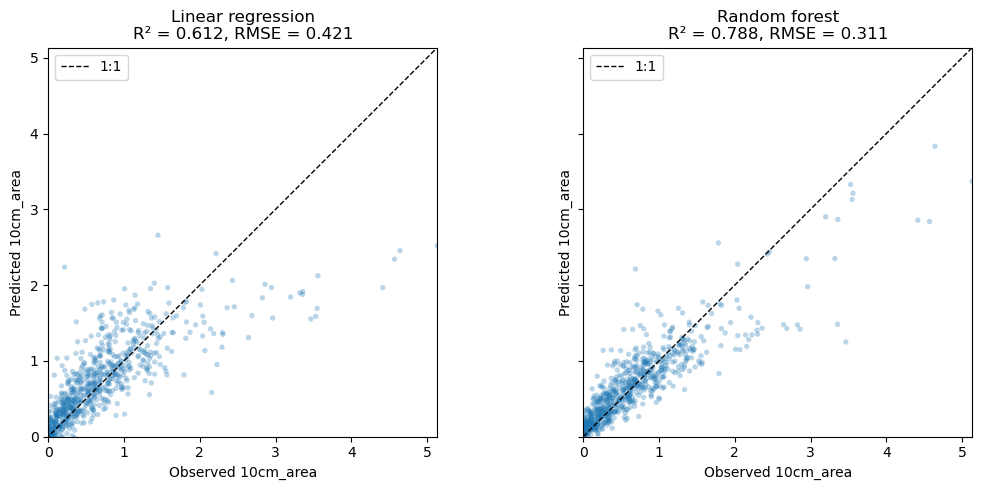

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)

for ax, y_pred, name, r2, rmse in zip(axes,
    [y_pred_lr, y_pred_rf],
    ['Linear regression', 'Random forest'],[r2_lr, r2_rf],
    [rmse_lr, rmse_rf]):
    ax.scatter(y, y_pred, alpha=0.3, s=15, edgecolor='none')
    
    # 1:1 reference line
    lims = [min(y.min(), y_pred.min()), max(y.max(), y_pred.max())]
    ax.plot(lims, lims, 'k--', linewidth=1, label='1:1')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    
    ax.set_xlabel('Observed 10cm_area')
    ax.set_ylabel('Predicted 10cm_area')
    ax.set_title(f'{name}\nR² = {r2:.3f}, RMSE = {rmse:.3f}')
    ax.set_aspect('equal')
    ax.legend()

plt.tight_layout()
plt.show()

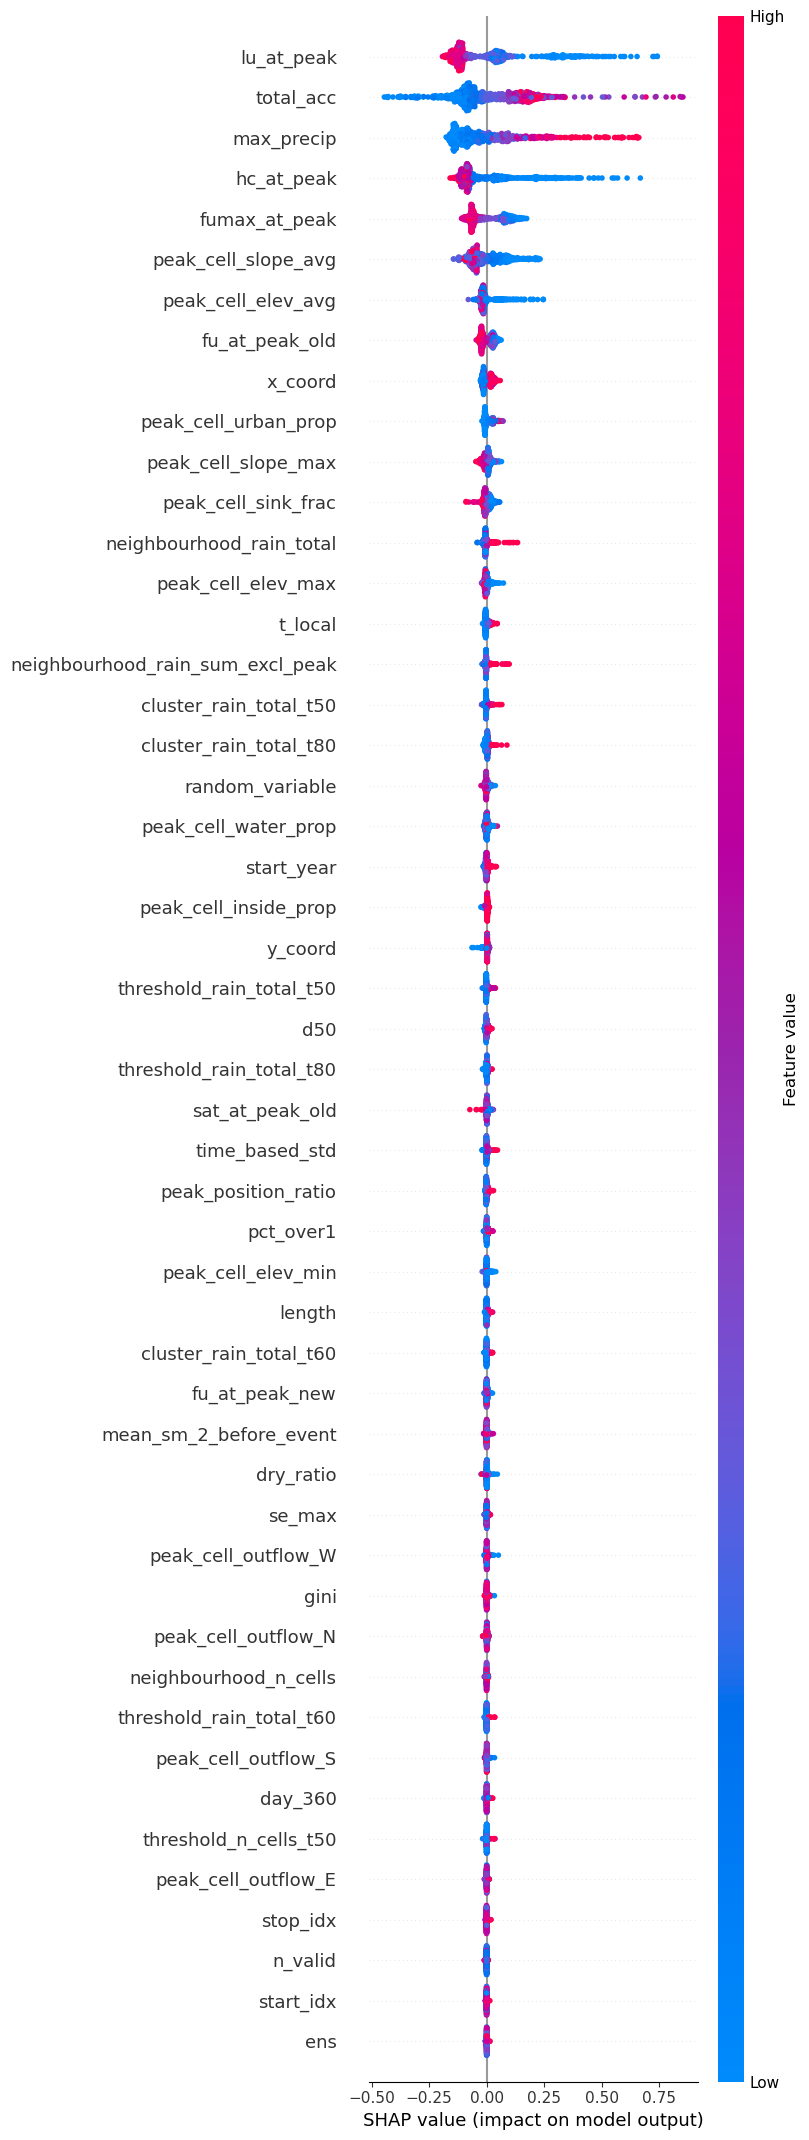

In [10]:
import shap 

# --- Now fit RF on everything, specifically for SHAP ---
rf.fit(X, y)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X)

shap.summary_plot(shap_values, X, show=True, max_display=50)

In [ ]:
# shap_interaction_values = explainer.shap_interaction_values(X)

# # attach back to a results dataframe, same as your period-comparison code
# results = subset.copy()
# results['y_true'] = y.values
# results['pred_lr'] = y_pred_lr
# results['pred_rf'] = y_pred_rf

# i = variables.index('fu_at_peak_new')  # adjust to your actual current predictor list
# j = variables.index('mean_sm_2_before_event')
# results['interaction_hc_moisture'] = shap_interaction_values[:, i, j] * 2

# for label, (y0, y1) in periods.items():
#     mask = (results['year'] >= y0) & (results['year'] <= y1)
#     vals = results.loc[mask, 'interaction_hc_moisture']
#     print(f"{label}: mean |interaction| = {vals.abs().mean():.4f}, mean = {vals.mean():.4f}")

### Compare performance across time periods

early (1980-2013)
mid (2014-2046)
late (2047-2080)


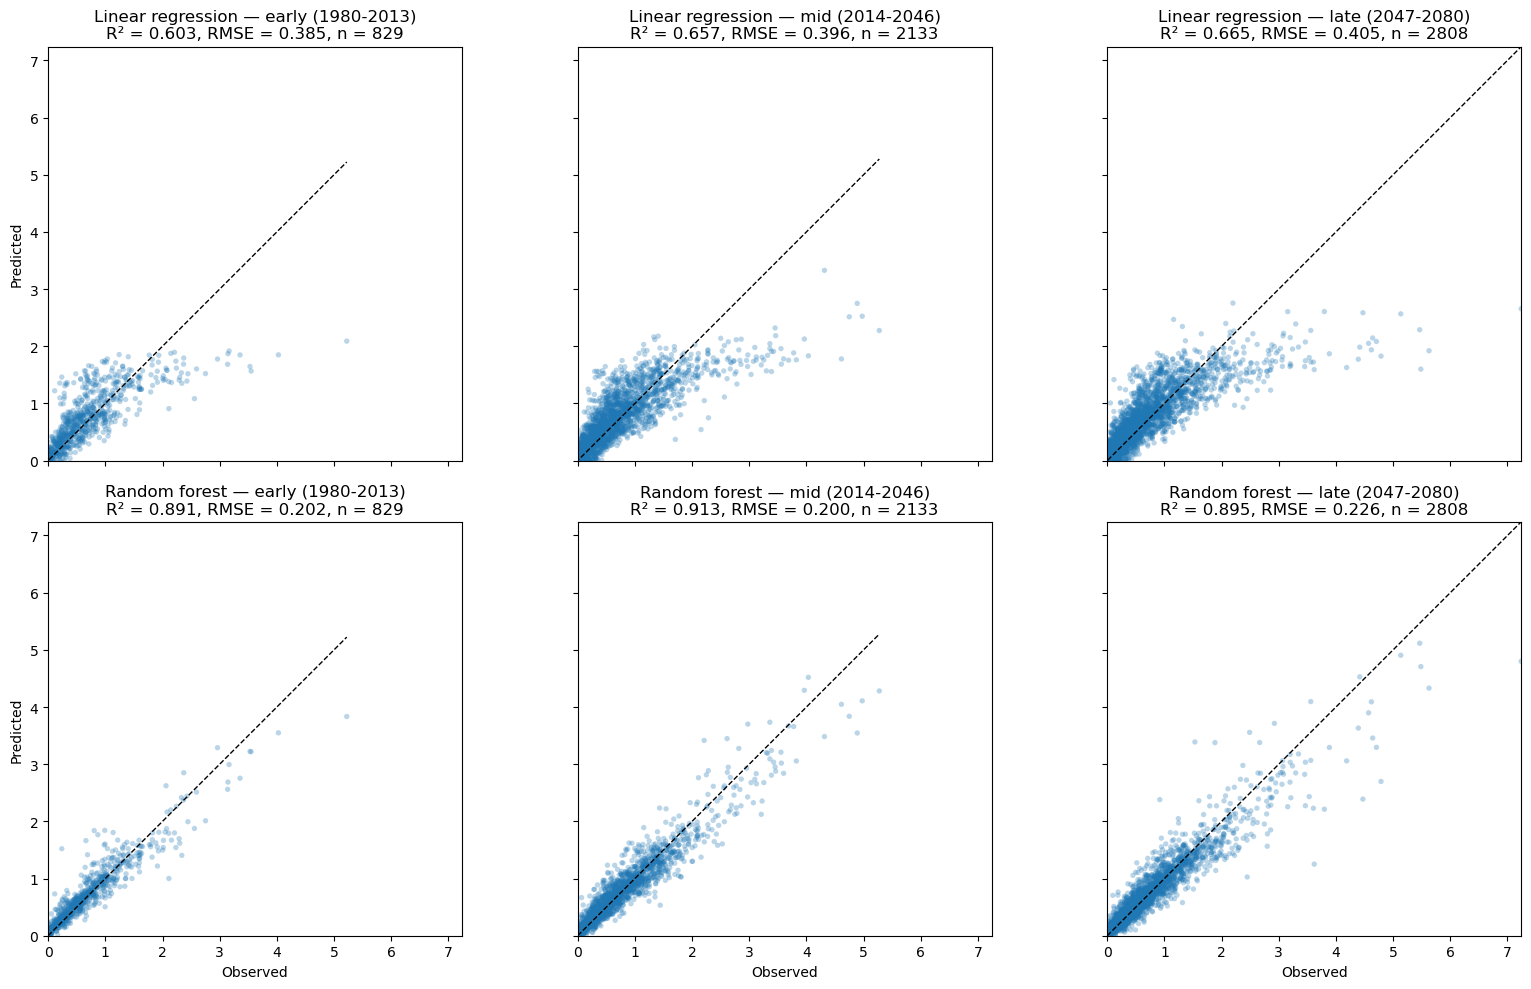

In [67]:
# Fit once on everything, same as before
y_pred_lr = cross_val_predict(lr, X, y, cv=cv, n_jobs=-1)
y_pred_rf = cross_val_predict(rf, X, y, cv=cv, n_jobs=-1)

# Attach predictions + period back onto the dataframe so you can slice by period
results = subset.copy()
results['y_true'] = y.values
results['pred_lr'] = y_pred_lr
results['pred_rf'] = y_pred_rf

periods = {'early (1980-2013)': (1980, 2013),'mid (2014-2046)':   (2014, 2046), 'late (2047-2080)':  (2047, 2080)}

fig, axes = plt.subplots(2, len(periods), figsize=(5.5*len(periods), 10), sharex=True, sharey=True)

for col, (label, (y0, y1)) in enumerate(periods.items()):
    print(label)
    mask = (results['start_year'] >= y0) & (results['start_year'] <= y1)
    sub = results.loc[mask]

    for row, (pred_col, name) in enumerate(zip(['pred_lr', 'pred_rf'], ['Linear regression', 'Random forest'])):
        ax = axes[row, col]
        r2 = r2_from_pred(sub['y_true'], sub[pred_col])
        rmse = rmse_from_pred(sub['y_true'], sub[pred_col])

        ax.scatter(sub['y_true'], sub[pred_col], alpha=0.3, s=15, edgecolor='none')
        lims = [min(sub['y_true'].min(), sub[pred_col].min()), max(sub['y_true'].max(), sub[pred_col].max())]
        ax.plot(lims, lims, 'k--', linewidth=1)
        ax.set_xlim(lims); ax.set_ylim(lims)
        ax.set_aspect('equal')
        ax.set_title(f'{name} — {label}\nR² = {r2:.3f}, RMSE = {rmse:.3f}, n = {mask.sum()}')
        if col == 0:
            ax.set_ylabel('Predicted')
        if row == 1:
            ax.set_xlabel('Observed')

plt.tight_layout()
plt.show()

In [ ]:
for label, (y0, y1) in periods.items():
    mask = (results['year'] >= y0) & (results['year'] <= y1)
    sub = results.loc[mask]
    top10 = sub[sub['y_true'] >= sub['y_true'].quantile(0.9)]
    
    bias_rf = (top10['pred_rf'] - top10['y_true']).mean()
    print(f"{label}: mean bias in top 10% events (RF) = {bias_rf:+.3f}, n = {len(top10)}")

In [71]:
rf.fit(X, y)  # single model, fit on everything
explainer = shap.TreeExplainer(rf)
shap_interaction_values = explainer.shap_interaction_values(X)  # computed once, for all rows

i = variables.index('fu_at_peak_new')
j = variables.index('mean_sm_2_before_event')
interaction_all = shap_interaction_values[:, i, j] * 2

results['interaction_hc_moisture'] = interaction_all

for label, (y0, y1) in periods.items():
    mask = (results['year'] >= y0) & (results['year'] <= y1)
    vals = results.loc[mask, 'interaction_hc_moisture']
    print(f"{label}: mean |interaction| = {vals.abs().mean():.4f}, "
          f"mean interaction = {vals.mean():.4f}, n = {mask.sum()}")

KeyboardInterrupt: 

In [72]:
# fig, ax = plt.subplots(figsize=(7, 5))
# for label, (y0, y1) in periods.items():
#     mask = (results['year'] >= y0) & (results['year'] <= y1)
#     ax.hist(results.loc[mask, 'interaction_hc_moisture'], bins=40, alpha=0.5,
#             density=True, label=label)
# ax.axvline(0, color='k', linewidth=0.8)
# ax.set_xlabel('SHAP interaction (HC × antecedent moisture)')
# ax.legend()
# plt.show()

In [34]:
import pickle
output = open('rf_subset.pkl', 'wb')
pickle.dump(rf, output)
output.close()

In [13]:
results = data.copy()
results['y_true'] = y.values
results['pred_lr'] = y_pred_lr
results['pred_rf'] = y_pred_rf

results['abs_err_lr'] = (results['y_true'] - results['pred_lr']).abs()
results['abs_err_rf'] = (results['y_true'] - results['pred_rf']).abs()

# Positive = RF does better at this point (smaller error)
results['rf_improvement'] = results['abs_err_lr'] - results['abs_err_rf']

results_sorted = results.sort_values('rf_improvement', ascending=False)
results_sorted

,max_precip,t_global,t_local,x_idx,y_idx,x_idx_global,y_idx_global,x_coord,y_coord,ens,...,lu_at_peak,Unnamed: 0,length,random_variable,y_true,pred_lr,pred_rf,abs_err_lr,abs_err_rf,rf_improvement
41789,85.165474,1016,3,3,6,59,155,97500.0,742500.0,15,...,0.062959,3074.0,53.0,-0.168871,2.5542,1.117937,2.255301,1.436263,0.298899,1.137364
41939,91.425987,1318,8,3,6,59,155,97500.0,742500.0,15,...,0.062959,3224.0,23.0,-1.849151,3.6054,1.201367,2.193444,2.404033,1.411956,0.992077
39199,70.895668,623,42,3,6,59,155,97500.0,742500.0,4,...,0.062959,484.0,53.0,0.651181,2.1420,1.075058,2.232081,1.066942,0.090081,0.976861
39210,82.991959,427,49,3,6,59,155,97500.0,742500.0,4,...,0.062959,495.0,138.0,0.857657,2.7882,1.212695,2.162331,1.575505,0.625869,0.949636
42091,127.306480,377,143,16,18,72,167,162500.0,802500.0,15,...,0.065472,3376.0,168.0,0.152576,0.7182,1.643338,0.665523,0.925138,0.052677,0.872461
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42027,99.661797,255,42,12,24,68,173,142500.0,832500.0,15,...,0.066359,3312.0,51.0,-0.559508,1.0728,1.103118,1.468026,0.030318,0.395226,-0.364908
39867,100.314255,2095,43,12,30,68,179,142500.0,862500.0,7,...,0.066592,1152.0,106.0,0.325482,0.8055,0.975003,1.446444,0.169503,0.640944,-0.471441
41048,111.040977,1275,9,13,31,69,180,147500.0,867500.0,11,...,0.065606,2333.0,16.0,-1.605621,1.2663,1.241713,0.745569,0.024587,0.520731,-0.496144
42033,82.808876,914,33,3,7,59,156,97500.0,747500.0,15,...,0.064608,3318.0,52.0,0.087851,1.0197,0.933519,1.669734,0.086181,0.650034,-0.563853


In [8]:
top_rf_wins = results_sorted.head(50)      # RF much better
top_lr_wins = results_sorted.tail(50)      # LR much better (or RF much worse)

top_rf_wins[variables + ['y_true', 'pred_lr', 'pred_rf']].describe()

,max_precip,month,mean_sm_2_before_event,fu_at_peak_new,fumax_at_peak,lu_at_peak,total_acc,peak_position_ratio,d50,gini,time_based_std,dry_ratio,max_quartile_index,random_variable,x_coord,y_coord,day_360,y_true,pred_lr,pred_rf
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,88.936805,7.580000,92.158139,0.001764,0.027252,0.066161,230.393549,0.515014,50.454808,0.894219,0.173761,8.563649,1.540000,-0.026529,122200.000000,762300.000000,201.140000,1.229634,1.082706,1.121618
std,24.344472,5.095376,20.693741,0.005569,0.002289,0.005945,121.072057,0.288426,25.587117,0.057455,0.084306,12.837045,1.164264,1.091046,23264.451291,45073.183122,157.683357,0.964168,0.273917,0.647806
min,34.083218,1.000000,0.000000,0.000000,0.026023,0.062959,69.627940,0.018868,1.707328,0.692336,0.005483,0.000000,0.000000,-2.241207,97500.000000,717500.000000,1.000000,0.031500,0.544949,0.100116
25%,71.678602,1.250000,92.156315,0.000000,0.026023,0.062959,137.116843,0.242566,26.442764,0.873850,0.123166,0.000000,0.000000,-0.726110,97500.000000,722500.000000,18.750000,0.453375,0.852071,0.600005
50%,89.356243,12.000000,98.674335,0.000040,0.026994,0.065532,231.881835,0.560569,53.340875,0.906413,0.164405,1.869322,2.000000,-0.046531,127500.000000,742500.000000,310.500000,0.772650,1.051633,0.955219
75%,107.136744,12.000000,100.792575,0.000358,0.027369,0.066431,280.560605,0.769231,72.294715,0.925598,0.254375,14.886364,2.750000,0.636010,132500.000000,801250.000000,347.000000,1.926225,1.286415,1.658063
max,128.090027,12.000000,107.653515,0.027369,0.037824,0.093629,523.305050,0.943182,93.946392,0.969718,0.319556,49.019608,3.000000,2.640238,167500.000000,862500.000000,360.000000,3.797100,1.643338,2.255301


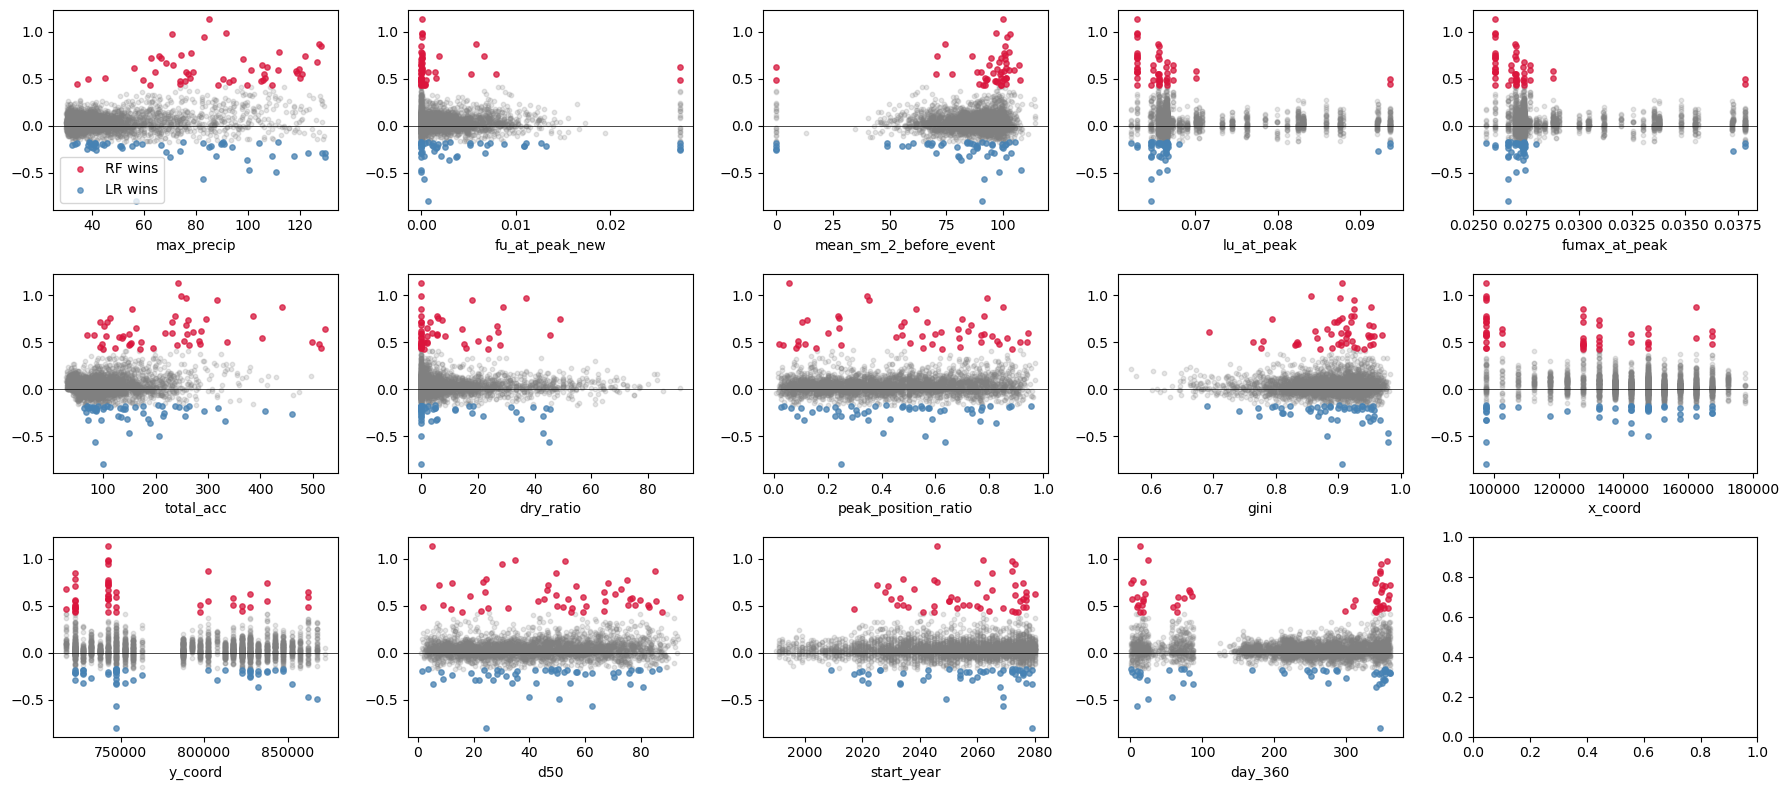

In [22]:
# import matplotlib.pyplot as plt

# fig, axes = plt.subplots(2, 4, figsize=(18, 8))
# key_vars = ['max_precip', 'fu_at_peak_new', 'mean_sm_2_before_event', 'lu_at_peak',
#             'total_acc', 'dry_ratio', 'peak_position_ratio', 'gini']

# for ax, var in zip(axes.flat, key_vars):
#     ax.scatter(results[var], results['rf_improvement'], alpha=0.2, s=10, color='grey')
#     ax.scatter(top_rf_wins[var], top_rf_wins['rf_improvement'], alpha=0.7, s=15, color='crimson')
#     ax.axhline(0, color='k', linewidth=0.5)
#     ax.set_xlabel(var)
#     ax.set_ylabel('RF improvement')

# plt.tight_layout()
# plt.show()

fig, axes = plt.subplots(3, 5, figsize=(18, 8))
key_vars = ['max_precip', 'fu_at_peak_new', 'mean_sm_2_before_event', 'lu_at_peak','fumax_at_peak',
            'total_acc', 'dry_ratio', 'peak_position_ratio', 'gini', 'x_coord', 'y_coord', 'd50',
           'start_year', 'day_360']

for ax, var in zip(axes.flat, key_vars):
    ax.scatter(results[var], results['rf_improvement'], alpha=0.2, s=10, color='grey')
    ax.scatter(top_rf_wins[var], top_rf_wins['rf_improvement'], alpha=0.7, s=15, color='crimson', label='RF wins')
    ax.scatter(top_lr_wins[var], top_lr_wins['rf_improvement'], alpha=0.7, s=15, color='steelblue', label='LR wins')
    ax.axhline(0, color='k', linewidth=0.5)
    ax.set_xlabel(var)

axes.flat[0].legend()
plt.tight_layout()
plt.show()

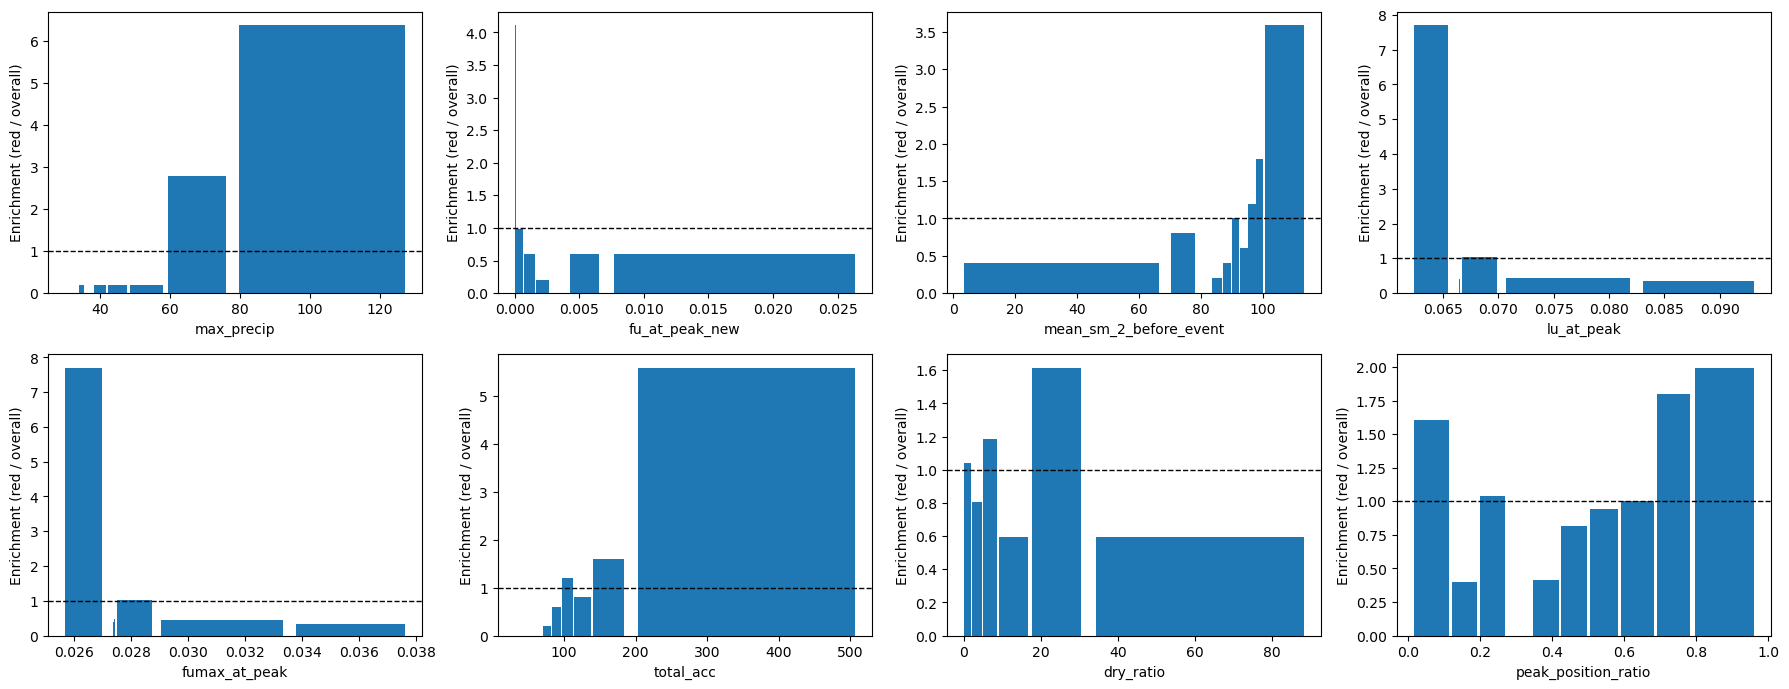

In [23]:
import numpy as np
import matplotlib.pyplot as plt

def enrichment_plot(var, data_full, data_red, n_bins=10, ax=None):
    bins = np.quantile(data_full[var].dropna(), np.linspace(0, 1, n_bins + 1))
    bins = np.unique(bins)  # in case of repeated values (e.g. fu_at_peak_new)
    
    full_counts, _ = np.histogram(data_full[var].dropna(), bins=bins)
    red_counts, _ = np.histogram(data_red[var].dropna(), bins=bins)
    
    full_frac = full_counts / full_counts.sum()
    red_frac = red_counts / red_counts.sum()
    
    enrichment = red_frac / full_frac  # >1 means over-represented among RF wins
    
    bin_centers = (bins[:-1] + bins[1:]) / 2
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 3))
    ax.bar(bin_centers, enrichment, width=np.diff(bins)*0.9)
    ax.axhline(1, color='k', linewidth=1, linestyle='--')
    ax.set_xlabel(var)
    ax.set_ylabel('Enrichment (red / overall)')
    return ax

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, var in zip(axes.flat, key_vars):
    enrichment_plot(var, results, top_rf_wins, ax=ax)
plt.tight_layout()
plt.show()

/home/kv25483/anaconda3/envs/geo_env2/lib/python3.10/site-packages/shap/explainers/_tree.py:87: ExperimentalWarning: Unable to check experimental integration status for RandomForestRegressor(random_state=42) object
  warnings.warn(


IndexError: list index out of range

In [69]:
shap_values = explainer.shap_values(X)

# Global summary: which variables matter most overall, and in which direction
shap.summary_plot(shap_values, X, show=True)

NameError: name 'explainer' is not defined

In [ ]:
periods = {
    'early (1980-2013)': (1980, 2013),
    'mid (2014-2046)':   (2014, 2046),
    'late (2047-2080)':  (2047, 2080),
}

period_interactions = {}

for label, (y0, y1) in periods.items():
    mask = (data['year'] >= y0) & (data['year'] <= y1)
    X_period = data.loc[mask, variables]
    y_period = data.loc[mask, '10cm_area']
    
    rf_period = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_period.fit(X_period, y_period)
    
    explainer_period = shap.TreeExplainer(rf_period)
    shap_int_period = explainer_period.shap_interaction_values(X_period)
    
    i = variables.index('fu_at_peak_new')
    j = variables.index('mean_sm_2_before_event')
    period_interactions[label] = shap_int_period[:, i, j] * 2

for label, vals in period_interactions.items():
    print(f"{label}: mean |interaction| = {np.abs(vals).mean():.4f}, "
          f"mean interaction = {vals.mean():.4f}")

In [62]:
subset[['fumax_at_peak', 'fu_at_peak_old', 'lu_at_peak']].std()
subset[['fumax_at_peak', 'fu_at_peak_old', 'lu_at_peak']].describe()

,fumax_at_peak,fu_at_peak_old,lu_at_peak
count,3226.000000,3226.000000,3226.000000
mean,0.028517,0.022475,0.069430
std,0.002781,0.002364,0.007228
min,0.025601,0.019591,0.062196
25%,0.027330,0.020994,0.066337
50%,0.027395,0.021601,0.066494
75%,0.027545,0.022723,0.067001
max,0.037824,0.032590,0.093629


In [73]:
from sklearn.model_selection import cross_val_score

def loco_test(X_full, y, drop_var, cv):
    X_reduced = X_full.drop(columns=[drop_var])
    rf_test = RandomForestRegressor(n_estimators=100, random_state=42)
    r2 = cross_val_score(rf_test, X_reduced, y, cv=cv, scoring='r2').mean()
    return r2

baseline_r2 = cross_val_score(rf, X, y, cv=cv, scoring='r2').mean()
print(f"Full model R²: {baseline_r2:.4f}\n")

for var in ['fumax_at_peak', 'fu_at_peak_old', 'lu_at_peak']:
    r2_dropped = loco_test(X, y, var, cv)
    print(f"Drop {var:20s} → R² = {r2_dropped:.4f}  (Δ = {baseline_r2 - r2_dropped:+.4f})")

Full model R²: 0.8143

Drop fumax_at_peak        → R² = 0.8143  (Δ = +0.0000)
Drop fu_at_peak_old       → R² = 0.8133  (Δ = +0.0010)
Drop lu_at_peak           → R² = 0.8131  (Δ = +0.0012)


Mean |interaction|: 0.0007


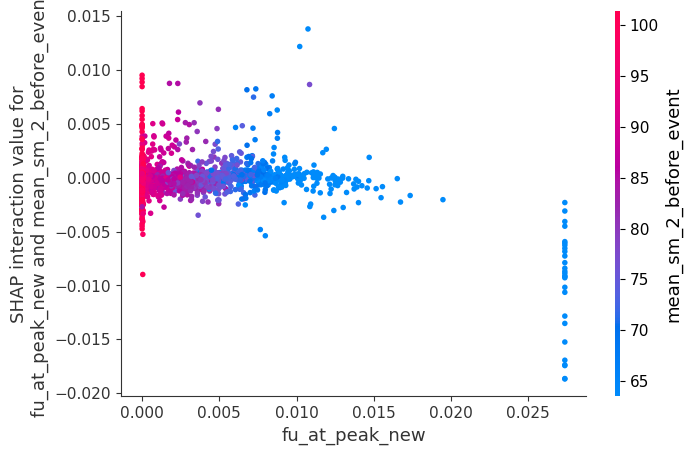

In [28]:
shap_interaction_values = explainer.shap_interaction_values(X)
i = variables.index('fu_at_peak_new')
j = variables.index('mean_sm_2_before_event')

interaction_hc_moisture = shap_interaction_values[:, i, j] * 2  
# *2 because SHAP splits each pairwise interaction symmetrically across [i,j] and [j,i]

print(f"Mean |interaction|: {np.abs(interaction_hc_moisture).mean():.4f}")

shap.dependence_plot(
    (i, j), shap_interaction_values, X,
    display_features=X)

In [29]:
n_vars = len(variables)
interaction_strength = np.zeros((n_vars, n_vars))

for a in range(n_vars):
    for b in range(n_vars):
        if a != b:
            interaction_strength[a, b] = np.abs(shap_interaction_values[:, a, b]).mean()

interaction_df = pd.DataFrame(interaction_strength, index=variables, columns=variables)

# Top interactions, excluding self-interactions (diagonal)
interaction_pairs = (
    interaction_df.where(np.triu(np.ones(interaction_df.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)
print(interaction_pairs.head(15))

max_precip     total_acc                 0.019500
               x_coord                   0.013785
               lu_at_peak                0.006429
               y_coord                   0.006060
               fumax_at_peak             0.005636
               peak_position_ratio       0.005184
total_acc      peak_position_ratio       0.005140
               x_coord                   0.004848
max_precip     d50                       0.004756
lu_at_peak     total_acc                 0.004463
max_precip     mean_sm_2_before_event    0.003903
lu_at_peak     x_coord                   0.002845
fumax_at_peak  total_acc                 0.002823
max_precip     time_based_std            0.002567
total_acc      d50                       0.002557
dtype: float64


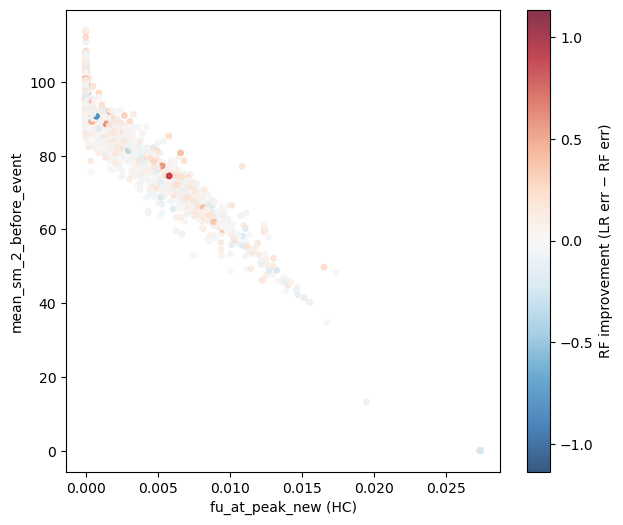

In [11]:
plt.figure(figsize=(7,6))
sc = plt.scatter(results['fu_at_peak_new'], results['mean_sm_2_before_event'],
                  c=results['rf_improvement'], cmap='RdBu_r', vmin=-results['rf_improvement'].abs().max(),
                  vmax=results['rf_improvement'].abs().max(), s=15, alpha=0.8)
plt.colorbar(sc, label='RF improvement (LR err − RF err)')
plt.xlabel('fu_at_peak_new (HC)')
plt.ylabel('mean_sm_2_before_event')
plt.show()

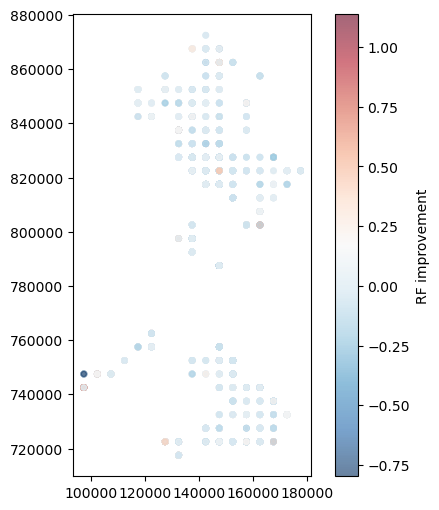

In [12]:
plt.figure(figsize=(6,6))
plt.scatter(results['x_coord'], results['y_coord'], c=results['rf_improvement'],
            cmap='RdBu_r', s=15, alpha=0.6)
plt.colorbar(label='RF improvement')
plt.gca().set_aspect('equal')
plt.show()

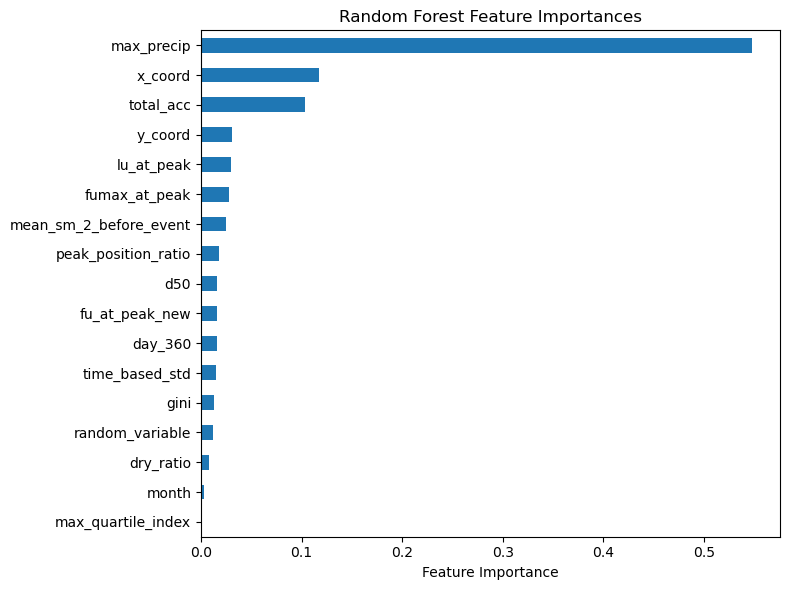

In [9]:
from sklearn.ensemble import RandomForestRegressor

importances = pd.Series(rf.feature_importances_,index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importances.sort_values().plot(kind="barh")
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importances")
plt.tight_layout()

In [31]:
from sklearn.inspection import permutation_importance

rf.fit(X, y)

perm = permutation_importance(rf, X, y,n_repeats=20,random_state=42,scoring='r2')

importance_rf = pd.DataFrame({'variable': X.columns,'importance': perm.importances_mean,'std': perm.importances_std
}).sort_values('importance', ascending=False)

print(importance_rf)

                  variable  importance       std
4            fumax_at_peak    0.493409  0.021007
5               lu_at_peak    0.338075  0.013852
0               max_precip    0.201461  0.010662
6                total_acc    0.194711  0.020446
2   mean_sm_2_before_event    0.040155  0.004651
9                     gini    0.017527  0.000946
3           fu_at_peak_new    0.016942  0.000585
10          time_based_std    0.012757  0.000543
8                      d50    0.011426  0.000734
7      peak_position_ratio    0.011381  0.000585
1                    month    0.011202  0.001005
11               dry_ratio    0.008259  0.000498
12      max_quartile_index    0.000673  0.000096


In [22]:
from sklearn.preprocessing import StandardScaler

X_scaled = pd.DataFrame(
    StandardScaler().fit_transform(X),
    columns=X.columns,
    index=X.index
)

lr_scaled = LinearRegression()
lr_scaled.fit(X_scaled, y)

importance_lr = pd.Series(
    lr_scaled.coef_,
    index=X.columns
).sort_values(key=abs, ascending=False)

print(importance_lr)

(np.float64(0.7598668489043616), np.float64(0.10471595232819793))